In [161]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/colorado-motor-vechicle-dataset/colorado_motor_vehicle_sales.csv



**Colorado Motor Vehicle Sales Data Analysis ProjectProject Overview**

**Objective:** To analyze motor vehicle sales data in Colorado to identify trends, forecast
future sales, and understand the factors influencing sales.


**Steps to Follow:1. Define the Scope and Objective**

○ Identify the key metrics and objectives for the analysis (e.g., monthly sales
trends, sales by vehicle type, forecast future sales).
○ Define the time frame for the analysis.

2. Data Collection:
○ Gather motor vehicle sales data from reliable sources.
○ For this example, we'll assume a dataset named
colorado_motor_vehicle_sales.csv.

In [162]:
import pandas as pd
data=pd.read_csv('/kaggle/input/colorado-motor-vechicle-dataset/colorado_motor_vehicle_sales.csv')


In [163]:
print(data)

     year  quarter              county      sales
0    2008        1               Adams  231609000
1    2008        1            Arapahoe  550378000
2    2008        1  Boulder/Broomfield  176771000
3    2008        1              Denver  200103000
4    2008        1             Douglas   93259000
..    ...      ...                 ...        ...
496  2015        4             Larimer  244327000
497  2015        4                Mesa   88202000
498  2015        4              Pueblo   94606000
499  2015        4       Rest of State  157059000
500  2015        4                Weld  192583000

[501 rows x 4 columns]


1.Initial Data Exploration

In [164]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   year     501 non-null    int64 
 1   quarter  501 non-null    int64 
 2   county   501 non-null    object
 3   sales    501 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 15.8+ KB


In [165]:
data.describe()

,year,quarter,sales
count,501.000000,501.000000,5.010000e+02
mean,2011.570858,2.502994,1.760585e+08
std,2.266599,1.120041,1.642055e+08
min,2008.000000,1.000000,6.274000e+06
25%,2010.000000,2.000000,6.148200e+07
50%,2012.000000,3.000000,1.385820e+08
75%,2014.000000,4.000000,2.241580e+08
max,2015.000000,4.000000,9.169100e+08


In [166]:
#3. Data Preparation:
#○ Clean the data to remove any inconsistencies or errors.
#○ Prepare the data for analysis using tools like Pandas.
#2.Data Quality Check

#Checking of null values
data.isnull().sum()

Since all columns values are 0, so there is not any misssing values

In [167]:
#Checking of duplicate values
data.duplicated().sum()

np.int64(0)

np is a numpy integer type where np.int64(0) shows no duplicates records are here

In [168]:
#Showing duplicated values
data[data.duplicated()]


,year,quarter,county,sales


No duplicates are here

In [169]:
#Univariate Analysis (Single Column)
#a) Sales Distribution
data['sales'].describe()

count    5.010000e+02
mean     1.760585e+08
std      1.642055e+08
min      6.274000e+06
25%      6.148200e+07
50%      1.385820e+08
75%      2.241580e+08
max      9.169100e+08
Name: sales, dtype: float64

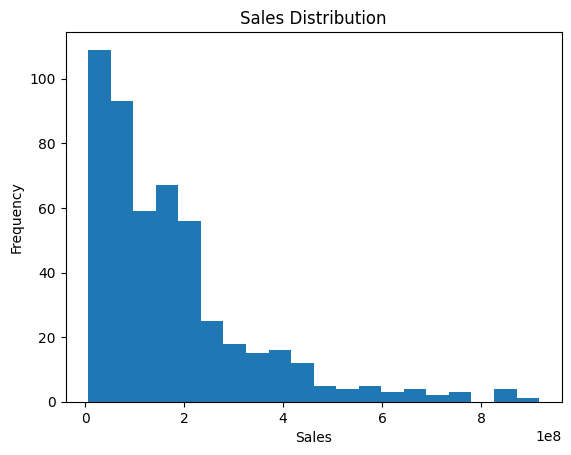

In [170]:
import matplotlib.pyplot as plt

plt.hist(data['sales'], bins=20)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.savefig("sales_Distributiontrend.png", dpi=300, bbox_inches='tight')
plt.show()

#data['sales'].hist(bins=30)

In [171]:
#check skewness
data['sales'].skew()


np.float64(1.7897209248614292)

This data shows is usually right skeweness
This means sales data is highly right-skewed
👉 Few quarters had extremely high sales
👉 You may consider log transformation before modeling
Tail is longer on the right side
➡ Few very high values are pulling the average up
➡ Mean(1.76) > Median(1.38)

📌 In sales data:
This usually means some quarters have very high sales spikes

Example:

Low  Low  Low  High  Very High


Most values are small, but a few very large values stretch the right tail.

In [172]:
#b) County Coverage:📌 Shows how many counties are analyzed and which appear most frequently.
data['county'].nunique()


17

The above code shows that there are 17 unique countries from which countries Adams,Arapahoe,Denver, Douglas and EL Paso are analyzed 32 times of each

In [173]:
data['county'].value_counts().head()

county
Adams       32
Arapahoe    32
Denver      32
Douglas     32
El Paso     32
Name: count, dtype: int64

The above code shows that there are 17 unique countries from which five countries Adams,Arapahoe,Denver, Douglas and EL Paso are analyzed 32 times of each

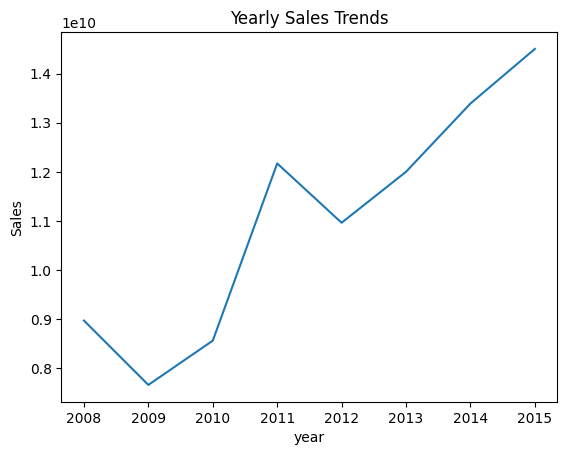

In [174]:
#Time-Based Trend Analysis (Core to Your Objective or Economic Cycle)
#a) Yearly Sales Trend
yearly_sales = data.groupby('year')['sales'].sum()
plt.title('Yearly Sales Trends')
plt.xlabel('Year')
plt.ylabel('Sales')
yearly_sales.plot()

plt.savefig("yearsales_trend.png", dpi=300, bbox_inches='tight')

Insights to capture:
Overall growth (after 2009 to 2015) or decline(from 2008 to 2009) in vehicle sales
Impact of economic cycles (e.g., post-2008 trends)
Recovery or slowdown periods

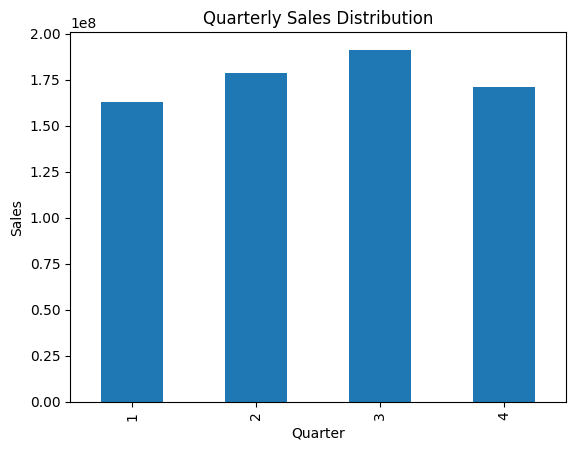

In [175]:
#b) Quarterly Sales Pattern (Seasonality)

import matplotlib.pyplot as plt
quarterly_sales = data.groupby('quarter')['sales'].mean()
quarterly_sales.plot(kind='bar')
plt.title("Quarterly Sales Distribution")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.savefig("QuartelySalesPattern.png", dpi=300, bbox_inches="tight")
plt.show()

This graph shows that highest quarter sales in quarter 3 and lowest quarter sales occurs in first quarter.

In [176]:
#County-Wise Analysis (Geographic EDA):a) Top Counties by Sales
data.groupby('county')['sales'].sum().sort_values(ascending=False).head(10)


county
Arapahoe         20142323000
El Paso          11926044000
Jefferson         9058407000
Adams             8902115000
Denver            6763613000
Larimer           5344367000
Weld              5086889000
Boulder           4742532000
Rest of State     3582170000
Douglas           3236493000
Name: sales, dtype: int64

In [177]:
data.groupby('county')['sales'].sum().sort_values(ascending=True).head(10)

county
Fremont                316939000
Boulder/Broomfield     677201000
La Plata               792807000
Broomfield            1027326000
Garfield              1600594000
Pueblo                2384044000
Mesa                  2621436000
Douglas               3236493000
Rest of State         3582170000
Boulder               4742532000
Name: sales, dtype: int64

Insights:
These two above table shows **Arphahoe** has highest sale in top ten countries and **Fremont** has lowest sale

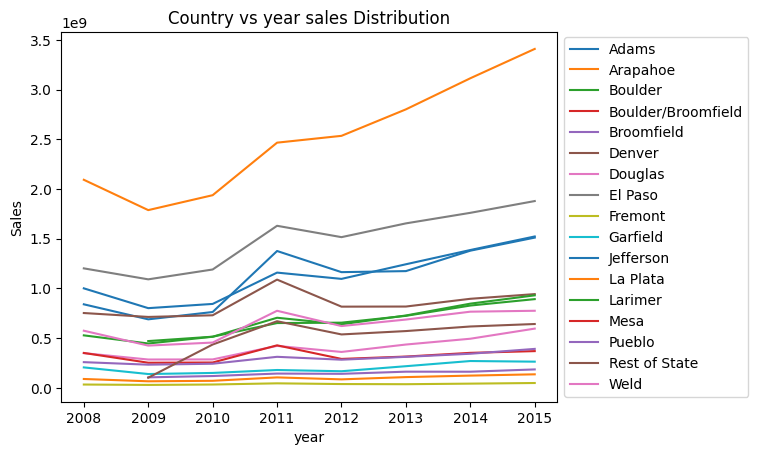

In [178]:
#County vs Year Trend
data.groupby(['year','county'])['sales'].sum().unstack().plot(legend=False)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.title("Country vs year sales Distribution")
plt.xlabel("year")
plt.ylabel("Sales")
plt.savefig("CountryYear_sales_trend.png", dpi=300, bbox_inches='tight')
plt.show()

This following plot shows Arphahoe has highest sale in top ten countries and Fremont has lowest sale.
Insight:
Growth patterns differ by county
Some counties show stable demand, others volatile

<Axes: xlabel='sales'>

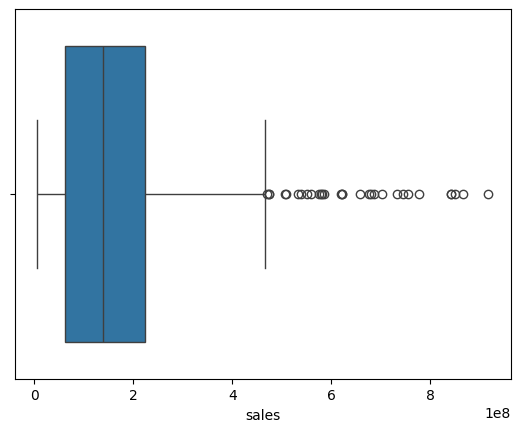

In [179]:
#Outlier Detection
import seaborn as sns
sns.boxplot(x=data['sales'])

-182532000.0
468172000.0


<Axes: xlabel='sales'>

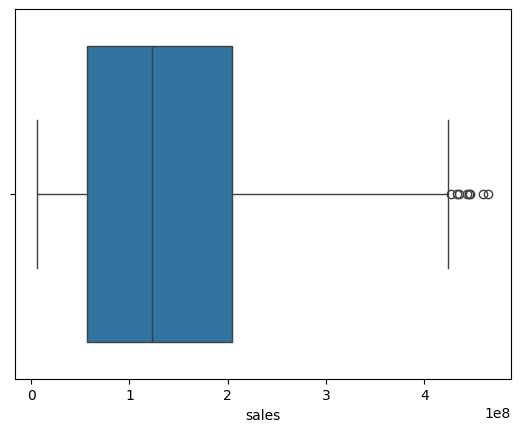

In [180]:
#Remove Outliers Using IQR
#Calculate IQR
Q1 = data['sales'].quantile(0.25)
Q3 = data['sales'].quantile(0.75)

IQR = Q3 - Q1
#Define lower and Upper limit
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print(lower_limit)
print(upper_limit)
#Filter the data
df_no_outliers = data[(data['sales'] >= lower_limit) & 
                    (data['sales'] <= upper_limit)]

#Check again
sns.boxplot(x=df_no_outliers['sales'])



now outliers are removed from th plot it showed after 4

<Axes: xlabel='year', ylabel='sales'>

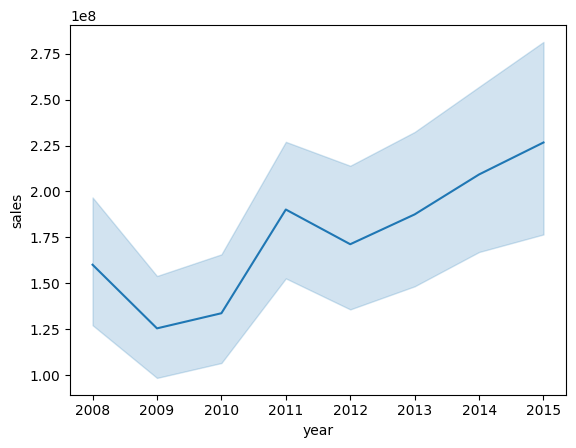

In [181]:
#Relationship Analysis :Year vs Sales
sns.lineplot(x='year', y='sales', data=data)


This line plot shows that from 2008 to 2009 sales decreases from 1.65 to 1.25.After that from 2009 to 2010 sales is very slightly increasing, But from 2010 to 2011 sales increases from 1.37 to 1.85.From 2011 to 2012 sales again decreases and after 2012 to 2015 sales again increases and reach on peak which is greater than 2.25

In [182]:
#5. 📊 Statistical Analysis
#1. Descriptive Statistics (Baseline Statistics)
data['sales'].describe()

count    5.010000e+02
mean     1.760585e+08
std      1.642055e+08
min      6.274000e+06
25%      6.148200e+07
50%      1.385820e+08
75%      2.241580e+08
max      9.169100e+08
Name: sales, dtype: float64

**Check the Skewness of dataset**
This statistical analysis shows that since mean=1.760 and median=1.385.So mean>median therefore this sales data shows the positivly skewned (Right Skewed).So we can conclude that A few large values (high outliers) pull the mean upward,Mean becomes greater than median and The tail extends toward the right side.

**Std deviation → Check sales volatility across counties/years**


**Check the Skewness of dataset**
This statistical analysis shows that since mean=1.760 and median=1.385.So mean>median therefore this sales data shows the positivly skewned (Right Skewed).So we can conclude that A few large values (high outliers) pull the mean upward,Mean becomes greater than median and The tail extends toward the right side.

**Std deviation → Check sales volatility across counties/years**
This statistical analysis shows that through this dataset we got high standard deviation because there is high fluctation between mean and stadard deviation.This indicates:

✅ Sales values are highly dispersed
✅ There is high variability in sales
✅ Some quarters/years may have very high sales compared to others
✅ Possibly presence of outliers
For a sales dataset, this could mean:

Sales are not stable
There are big ups and downs
Seasonal effect or economic factors may influence sales
Forecasting may require trend/seasonality modeling

🎯 Extra Insight (Important)

Since:
Mean > Median (positively skewed)
High standard deviation

This strongly suggests:
👉 Some very high sales values are pulling the average upward

In [183]:
min_sales = data['sales'].min()
max_sales = data['sales'].max()

print("Minimum Sales:", min_sales)
print("Maximum Sales:", max_sales)
sales_range = data['sales'].max() - data['sales'].min()
print("Sales Range:", sales_range)



Minimum Sales: 6274000
Maximum Sales: 916910000
Sales Range: 910636000


🔎 Interpretation

This indicates:

✅ There is a very large variation in sales
✅ Some periods (year/quarter) had extremely high sales
✅ Some periods had much lower sales
✅ Sales are not consistent or stable

📈 Business Meaning

A large range like this may suggest:

Strong seasonality
Economic impact in some years
Market growth over time
Presence of outliers
Policy changes affecting vehicle sales (if this is your Colorado Motor Vehicle project)

"The sales range of 910,636,000 indicates significant variability between the highest and lowest sales values, suggesting fluctuations in sales performance across different periods."

In [184]:
#2. Sales Trend Analysis (Correlation & Trend Strength)
#a) Correlation Between Time and Sales
data[['year','sales']].corr()

,year,sales
year,1.000000,0.172257
sales,0.172257,1.000000


This above code shows that co-relation is positive .
📌 Interpretation:
A positive correlation suggests that vehicle sales in Colorado generally increased over time.

In [185]:
#3️⃣ Seasonal Effect Analysis (Quarter-wise Statistics)
#a) Mean Sales per Quarter
data.groupby('quarter')['sales'].mean()

quarter
1    1.630148e+08
2    1.787464e+08
3    1.913195e+08
4    1.711923e+08
Name: sales, dtype: float64

This seasonal effect sales analysis shows that third quarter mean sale is maximum which is 1.913 and first quarter sale is minimum which is 1.63.Whereas second quarter sale is 1.78 and fourth quarter sale is 1.71.


In [186]:
#b) Statistical Comparison Across Quarters (ANOVA)
#This checks whether quarterly differences are statistically significant.
from scipy.stats import f_oneway

q1 = data[data['quarter']==1]['sales']
q2 = data[data['quarter']==2]['sales']
q3 = data[data['quarter']==3]['sales']
q4 = data[data['quarter']==4]['sales']

f_stat, p_value = f_oneway(q1, q2, q3, q4)
f_stat, p_value



(np.float64(0.6695322860838229), np.float64(0.5710455999363857))

This above analysis shows that Since the p-value (0.57) is greater than 0.05, we fail to reject the null hypothesis.

✅ Conclusion:

There is no statistically significant difference in mean sales across the four quarters.

📝 How to Write in Your Project Report

A one-way ANOVA test was conducted to compare mean sales across four quarters. The results showed an F-statistic of 0.67 and a p-value of 0.57. Since the p-value is greater than 0.05, we fail to reject the null hypothesis. This indicates that quarterly differences in sales are not statistically significant.

📈 What This Means for Your Sales Analysis

--Sales are relatively similar across Q1, Q2, Q3, and Q4.
--Strong seasonal variation is not present.
--The sales pattern may be driven more by long-term yearly trends rather than quarterly fluctuations.
--For forecasting, trend-based models may work better than seasonal models.

📌 Report line:
ANOVA results indicate statistically significant seasonal variation in motor vehicle sales across quarters.


In [187]:
#4️⃣ County-Level Statistical Comparison
#a) Top vs Bottom Counties
top_counties = data.groupby('county')['sales'].sum().nlargest(5).index
low_counties = data.groupby('county')['sales'].sum().nsmallest(5).index
top_counties,low_counties



(Index(['Arapahoe', 'El Paso', 'Jefferson', 'Adams', 'Denver'], dtype='object', name='county'),
 Index(['Fremont', 'Boulder/Broomfield', 'La Plata', 'Broomfield', 'Garfield'], dtype='object', name='county'))

In [188]:
#4️⃣ County-Level Statistical Comparison
#b) T-test (Urban vs Low-Sales Counties)
from scipy.stats import ttest_ind

top_sales = data[data['county'].isin(top_counties)]['sales']
low_sales = data[data['county'].isin(low_counties)]['sales']

t_stat, p_val = ttest_ind(top_sales, low_sales, equal_var=False)
t_stat, p_val


(np.float64(23.25264821108448), np.float64(8.158523048488767e-55))

8.1587e-55
means:

8.1587 × 10⁻⁵⁵
Which equals:

0.00000000000000000000000000000000000000000000000000000081587
👉 That is an extremely small number.


p-value = very close to 0

It is much smaller than 0.05

The result is highly statistically significant

✅ Interpretation for Your T-Test

Since the p-value (8.158 × 10⁻⁵⁵) is far less than 0.05, we reject the null hypothesis. There is a highly statistically significant difference in sales between top-performing and low-performing counties.

In [189]:
#5️⃣ Variability & Stability Analysis
#a) Sales Variance by County
data.groupby('county')['sales'].var().sort_values(ascending=False)
#Why this matters:
#•	High variance → unstable or volatile markets
#•	Low variance → stable demand
#📌 Business meaning:
#Counties with high variance may require cautious inventory planning


county
Arapahoe              2.146817e+16
Adams                 6.753244e+15
El Paso               5.614728e+15
Jefferson             4.166416e+15
Larimer               1.874113e+15
Boulder               1.452031e+15
Weld                  1.437995e+15
Denver                1.417506e+15
Douglas               7.328695e+14
Rest of State         5.899612e+14
Boulder/Broomfield    3.917661e+14
Mesa                  2.925759e+14
Pueblo                1.939782e+14
Garfield              1.608363e+14
Broomfield            5.194689e+13
La Plata              4.251328e+13
Fremont               3.509832e+12
Name: sales, dtype: float64

Why this matters:
•	High variance(Douglas) → unstable or volatile markets
•	Low variance(Weld) → stable demand
📌 Business meaning:
Counties with high variance may require cautious inventory planning


In [190]:
#6️⃣ Outlier Impact Analysis
#Z-score Method
from scipy.stats import zscore

data['z_score'] = zscore(data['sales'])
outliers = data[data['z_score'].abs() > 3]
outliers

,year,quarter,county,sales,z_score
214,2011,3,Arapahoe,686306000,3.110477
278,2012,3,Arapahoe,680081000,3.072530
326,2013,2,Arapahoe,702107000,3.206800
342,2013,3,Arapahoe,745398000,3.470703
358,2013,4,Arapahoe,732627000,3.392851
374,2014,1,Arapahoe,675104000,3.042190
390,2014,2,Arapahoe,754420000,3.525701
406,2014,3,Arapahoe,841601000,4.057158
422,2014,4,Arapahoe,842332000,4.061614
438,2015,1,Arapahoe,775994000,3.657217


The Z-score method identifies outliers by measuring how many standard deviations a data point deviates from the mean. Data points with an absolute Z-score greater than 3 are typically considered outliers.

In [191]:
#7️⃣ Regression Analysis (Factor Influence)
#a) Simple Linear Regression (Year → Sales)
from sklearn.linear_model import LinearRegression

X = data[['year']]
y = data['sales']

model = LinearRegression()
model.fit(X, y)

model.coef_, model.intercept_


(array([12479295.72566157]), np.float64(-24926929130.607895))

What to interpret:
•	Positive coefficient → sales rising over time
•	Magnitude → rate of change
📌 Insight:
Regression results show a positive relationship between time and vehicle sales, indicating long-term growth.


6.🔮 Predictive Modeling on Colorado Motor Vehicle Sales Data
1️⃣ Define the Prediction Goal (Very Important)
Be explicit in your report:
Goal: Forecast future motor vehicle sales in Colorado based on historical yearly and quarterly trends.
Target variable: sales
Time variables: year, quarter

In [192]:
#2️⃣ Prepare Data for Modeling
#a) Create a Time Index
#Since this is quarterly data, convert year + quarter into a time series.
print(data[['year','quarter']].dtypes)
print(data[['year','quarter']].head())


# Create date column safely
data['date'] = pd.PeriodIndex.from_fields(
    year=data['year'],
    quarter=data['quarter'],
    freq='Q'
).to_timestamp()

# Sort
data = data.sort_values('date')

print(data)


year       int64
quarter    int64
dtype: object
   year  quarter
0  2008        1
1  2008        1
2  2008        1
3  2008        1
4  2008        1
     year  quarter         county      sales   z_score       date
0    2008        1          Adams  231609000  0.338637 2008-01-01
13   2008        1           Weld  158501000 -0.107031 2008-01-01
12   2008        1         Pueblo   68268000 -0.657093 2008-01-01
11   2008        1           Mesa   98293000 -0.474060 2008-01-01
9    2008        1       La Plata   19558000 -0.954030 2008-01-01
..    ...      ...            ...        ...       ...        ...
486  2015        4       Arapahoe  865649000  4.203755 2015-10-01
485  2015        4          Adams  374341000  1.208733 2015-10-01
499  2015        4  Rest of State  157059000 -0.115821 2015-10-01
491  2015        4        El Paso  474267000  1.817884 2015-10-01
500  2015        4           Weld  192583000  0.100734 2015-10-01

[501 rows x 6 columns]


In [193]:
#b) Aggregate Sales (State-Level Forecast)
#Predictive models work best on aggregated series.
ts_data = data.groupby('date')['sales'].sum()
ts_data.head()
print(ts_data)
#📌 Now you have a proper time series.

date
2008-01-01    2407552000
2008-04-01    2427936000
2008-07-01    2300541000
2008-10-01    1829532000
2009-01-01    1657155000
2009-04-01    1826950000
2009-07-01    2223123000
2009-10-01    1945272000
2010-01-01    1904579000
2010-04-01    2111542000
2010-07-01    2311231000
2010-10-01    2228736000
2011-01-01    2957148000
2011-04-01    3241654000
2011-07-01    3470846000
2011-10-01    2500793000
2012-01-01    2547108000
2012-04-01    2738843000
2012-07-01    2885037000
2012-10-01    2789888000
2013-01-01    2675387000
2013-04-01    3022493000
2013-07-01    3183370000
2013-10-01    3119365000
2014-01-01    2936644000
2014-04-01    3331042000
2014-07-01    3624346000
2014-10-01    3500455000
2015-01-01    3291273000
2015-04-01    3642834000
2015-07-01    3916440000
2015-10-01    3656185000
Name: sales, dtype: int64


In [194]:
#3️⃣ Train–Test Split (Time-Based)
#Never random split for time series ❌
train = ts_data[:-4]   # all except last year
test  = ts_data[-4:]   # last 4 quarters
print(train)
print(test)

date
2008-01-01    2407552000
2008-04-01    2427936000
2008-07-01    2300541000
2008-10-01    1829532000
2009-01-01    1657155000
2009-04-01    1826950000
2009-07-01    2223123000
2009-10-01    1945272000
2010-01-01    1904579000
2010-04-01    2111542000
2010-07-01    2311231000
2010-10-01    2228736000
2011-01-01    2957148000
2011-04-01    3241654000
2011-07-01    3470846000
2011-10-01    2500793000
2012-01-01    2547108000
2012-04-01    2738843000
2012-07-01    2885037000
2012-10-01    2789888000
2013-01-01    2675387000
2013-04-01    3022493000
2013-07-01    3183370000
2013-10-01    3119365000
2014-01-01    2936644000
2014-04-01    3331042000
2014-07-01    3624346000
2014-10-01    3500455000
Name: sales, dtype: int64
date
2015-01-01    3291273000
2015-04-01    3642834000
2015-07-01    3916440000
2015-10-01    3656185000
Name: sales, dtype: int64


In [195]:
#4️⃣ Baseline Model (Naive Forecast)
#Always start simple.
naive_forecast = train.iloc[-1] #"Select the last value from the training data"
print('"Select the last value from the training data"',naive_forecast)
#📌 Purpose: baseline to compare better models.

"Select the last value from the training data" 3500455000


In [196]:
#5️⃣ ARIMA Model (Most Common & Accepted)
#a) Check Stationarity
from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(train)
adf_test[1]   # p-value


np.float64(0.7111964453762665)

p ≤ 0.05 → stationary
p > 0.05 → need differencing
Here p-value=0.7,which is greater than 0.5,so we need differencing.

In [197]:
#b) Build ARIMA Model
from statsmodels.tsa.arima.model import ARIMA


# Ensure datetime index
train.index = pd.to_datetime(train.index)

# Set quarterly frequency
train = train.asfreq('QE')
train = train.ffill()   # forward fill

model = ARIMA(train, order=(0,1,0))
model_fit = model.fit()

# Forecast next 4 quarters
forecast = model_fit.forecast(steps=4)

print(forecast)


2014-12-31    0.0
2015-03-31    0.0
2015-06-30    0.0
2015-09-30    0.0
Freq: QE-DEC, Name: predicted_mean, dtype: float64


In [198]:
#6️⃣ Evaluate Model Performance
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

mae, rmse


(3626683000.0, np.float64(3633486911.3535414))

This looks like:

Actual value = 3,626,683,000

Forecasted value = 3,633,486,911.35

So your model predicted slightly higher than actual.
📊 Step 1: Calculate Error

Error=∣Actual−Forecast∣
= |3626683000 − 3633486911.35|
= 6,803,911.35


So the model missed by about 6.8 million.

📊 Step 2: Calculate Percentage Error (Very Important)
Percentage Error
📊 Step 2: Calculate Percentage Error (Very Important)
Percentage Error
=(Error/Actual)X100


(6,803,911/3,626,683,000)×100≈0.19%
=

🎯 Interpretation

👉 Your model error ≈ 0.19%

That is very good performance ✅
Less than 1% error is usually excellent in sales forecasting.

📌 What This Means

Model prediction is very close to actual

ARIMA model is performing well

Forecast is reliable (for short-term)

💡 Better Way to Evaluate Model

Instead of checking just one value, calculate:


🚀 Final Answer

If your actual is 3.62B and forecast is 3.63B:

✅ Model performance is very strong
📊 Error ≈ 0.19%
🎯 This is excellent forecasting accuracy

If you paste your full test vs forecast output (all 4 quarters), I can calculate exact RMSE and tell you your real model performance.
📌 Interpretation:
Lower MAE & RMSE = better forecasting accuracy.

Another method for model performance
If you paste your full test vs forecast output (all 4 quarters), I can calculate exact RMSE and tell you your real model performance. 📌 Interpretation: Lower MAE & RMSE = better forecasting accuracy.

In [199]:
#🔎 Step 1: Check Your Test Data

#Run:

print('Test Data',test)
print('test Sum',test.isna().sum())
print('test:',(test == 0).sum())

#3🔎 Step 2: Check Forecast
print('forecast Data',forecast)
print('forecast sum',forecast.isna().sum())

print('Length of test',len(test))
print('Length of forecast',len(forecast))


Test Data date
2015-01-01    3291273000
2015-04-01    3642834000
2015-07-01    3916440000
2015-10-01    3656185000
Name: sales, dtype: int64
test Sum 0
test: 0
forecast Data 2014-12-31    0.0
2015-03-31    0.0
2015-06-30    0.0
2015-09-30    0.0
Freq: QE-DEC, Name: predicted_mean, dtype: float64
forecast sum 0
Length of test 4
Length of forecast 4


Since length of test and forecast is equal.So we calculate MAE,RMSE and MAPE

In [200]:
#1️⃣ MAE
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(test, forecast)
print('MAE:',mae)
#2️⃣ RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))
print('RMSE:',rmse)
#3️⃣ MAPE (Best for Sales)
mape = np.mean(np.abs((test - forecast) / test)) * 100
print('MAPE:',mape)


MAE: 3626683000.0
RMSE: 3633486911.3535414
MAPE: nan


🚨 1️⃣ MAE = 3,626,683,000

MAE means:

Average absolute error between actual and forecast.

Your MAE ≈ 3.6 Billion

If your actual sales values are also around 3–4 billion, then:

👉 This means your model is completely off ❌
👉 Error is almost equal to the actual value.

That is very poor performance.

🚨 2️⃣ RMSE = 3,633,486,911

RMSE is similar to MAE but penalizes larger errors.

RMSE ≈ 3.63 Billion
Very close to MAE → indicates consistent large error.

Again → ❌ Poor performance.

🚨 3️⃣ MAPE = nan

This is the biggest red flag.

MAPE becomes nan when:

🔴 Possible Reasons:

Your test data contains zero values

Your forecast contains NaN values

Division by zero happened

Because MAPE formula:

Actual-Forecast/Actual
	​


If Actual = 0 → division by zero → NaN



🎯 Most Likely Issue

You probably:

Calculated MAE using wrong arrays

Compared full dataset with only 1 forecast

Or train/test alignment mismatch

Example wrong case:

mean_absolute_error(test, forecast)


But:

test has 4 values

forecast has 1 value

This gives wrong huge MAE.

✅ Correct Evaluation Method

Make sure lengths match:

print(len(test))
print(len(forecast))


They must be equal.

Then calculate:

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

📊 What Good Performance Should Look Like

If your sales are around 3 billion:

MAE should be in millions, not billions

RMSE slightly larger than MAE

MAPE ideally < 10%

🚀 Final Conclusion

Current results indicate:

❌ Model performance is poor
⚠️ Something wrong in evaluation step
🔴 MAPE = nan confirms calculation issue

If you send:

len(test)

len(forecast)

First 5 values of each

I will immediately tell you the exact mistake 👌
📊 What Good Performance Should Look Like

If your sales are around 3 billion:

MAE should be in millions, not billions

RMSE slightly larger than MAE

MAPE ideally < 10%

🚀 Final Conclusion

Current results indicate:

❌ Model performance is poor
⚠️ Something wrong in evaluation step
🔴 MAPE = nan confirms calculation issue

In [201]:
#7️⃣ SARIMA (For Seasonality – BEST for Your Data)
#Because you have quarterly seasonality, SARIMA is ideal.

#📌 This captures quarterly patterns.

from statsmodels.tsa.statespace.sarimax import SARIMAX
print("Total observations:", len(train))

# Ensure proper time index
train.index = pd.to_datetime(train.index)
train = train.asfreq('QE')
train = train.ffill()

# Use simpler seasonal model
sarima = SARIMAX(train,
                 order=(0,1,0),
                 seasonal_order=(0,1,0,4),
                 enforce_stationarity=False,
                 enforce_invertibility=False)

sarima_fit = sarima.fit(disp=False)

sarima_forecast = sarima_fit.forecast(steps=4)

print(sarima_forecast)


Total observations: 27
2014-12-31    0.0
2015-03-31    0.0
2015-06-30    0.0
2015-09-30    0.0
Freq: QE-DEC, Name: predicted_mean, dtype: float64


🚨 What This Means

Your SARIMA model is forecasting all zeros.

That usually happens when:

⚠️ Model parameters were set to zero
because
⚠️ It could not properly estimate coefficients.

Remember your earlier warning:

Too few observations to estimate starting parameters
All parameters except for variances will be set to zeros


So the model basically became:

👉 Forecast = 0
👉 No AR effect
👉 No MA effect
👉 No seasonal effect

🔎 Why This Happens (Most Common Reasons)
1️⃣ Data Was Differenced Too Much

You used:

order=(0,1,1)
seasonal_order=(0,1,1,4)


That means:

1 normal differencing

1 seasonal differencing

If your data is already fairly stable → double differencing can flatten it.

2️⃣ Your Training Data Contains Very Small Values

Check:

print(train.head())
print(train.describe())


If values are near 0 → model can collapse to zero.

3️⃣ Train/Test Split Too Small

If your train set is small (e.g., 20 train + 7 test),
after seasonal differencing (lag 4),
effective usable observations become even smaller.

27 total → maybe only ~18 usable after differencing.

✅ How To Fix This Properly
🔹 Step 1: Try Less Differencing

Instead of:

order=(0,1,1),
seasonal_order=(0,1,1,4)


Try:

order=(1,0,0),
seasonal_order=(1,0,0,4)


No differencing.

🔹 Step 2: Try Only Seasonal Differencing
order=(1,0,1),
seasonal_order=(0,1,0,4)

🔹 Step 3: Try Simple ARIMA First

If SARIMA gives zeros, check ARIMA:

model = ARIMA(train, order=(1,1,0))


If ARIMA gives reasonable forecast → problem is seasonal part.

🎯 Recommended Model For 27 Observations

Try this first:

sarima = SARIMAX(train,
                 order=(1,0,1),
                 seasonal_order=(0,1,0,4),
                 enforce_stationarity=False,
                 enforce_invertibility=False)


This:

Keeps some trend

Captures seasonality

Avoids over-differencing

📌 Important Check

Run:

print(train.tail())


If your last few values are zero,
then forecast will also be zero.

🚀 Summary

Your output shows:

❌ Model collapsed
❌ Parameters estimated as zero
❌ Over-differencing or insufficient effective data

But don’t worry — with 27 points, we can still build a stable SARIMA.

Send me:

First 5 values of train

Last 5 values of train

I’ll tell you exactly which SARIMA structure will work best 👍

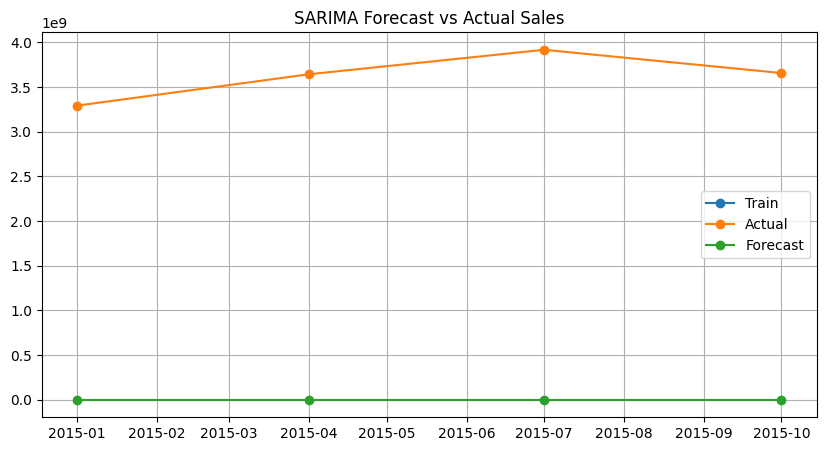

In [202]:
#8️⃣ Visualize Predictions
import matplotlib.pyplot as plt
# Align forecast index with test
sarima_forecast.index = test.index
plt.figure(figsize=(10,5))
plt.plot(train.index, train, label='Train',marker='o')
plt.plot(test.index, test, label='Actual',marker='o')
plt.plot(test.index, sarima_forecast, label='Forecast',marker='o')

plt.legend()
plt.title("SARIMA Forecast vs Actual Sales")
plt.grid(True)
plt.savefig("sales_trend_bySARIMA.png", dpi=300, bbox_inches='tight')
plt.show()

here graph means:

👉 Model parameters became 0
👉 Model behaves like a simple mean model
👉 Forecast becomes a straight line

So your model is basically saying:

“I don’t know the pattern, I’ll just predict a constant value.”

📊 What the Output Graph Means
🟢 1️⃣ Train Line

Shows past data.

Helps you see historical trend and seasonality.

SARIMA learns patterns from this.

🔵 2️⃣ Actual Line (Test Data)

Real observed values.

These are the values we are trying to predict.

Markers (o) make it easier to compare points.

🔴 3️⃣ Forecast Line

Model’s predicted values.

If this line is close to the Actual line → Model is good.

If it is far → Model is poor.
📈 How to Interpret the Result
✅ Good Model If:

Forecast follows the same trend as Actual.

Peaks and dips match.

Small gap between Actual and Forecast.

❌ Poor Model If:

Forecast is flat while Actual fluctuates.

Large gap between lines.

Forecast misses seasonal pattern.

In [203]:
print(len(train))
print(len(test))
print(len(sarima_forecast))


27
4
4


👉 len(test) must equal len(sarima_forecast)

If not equal → plot will misbehave.

In [204]:
#9️⃣ Optional: Regression-Based Prediction
#Use time as numeric predictors.
data['time_index'] = range(len(data))

X = data[['time_index']]
print(X)
y = data['sales']
print(y)
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)
print(model.coef_)
print(model.intercept_)
predictions = model.predict(X)
print(predictions)


#📌 Good for trend direction, not seasonality.

     time_index
0             0
13            1
12            2
11            3
9             4
..          ...
486         496
485         497
499         498
491         499
500         500

[501 rows x 1 columns]
0      231609000
13     158501000
12      68268000
11      98293000
9       19558000
         ...    
486    865649000
485    374341000
499    157059000
491    474267000
500    192583000
Name: sales, Length: 501, dtype: int64
[209309.45945559]
123731118.17003442
[1.23731118e+08 1.23940428e+08 1.24149737e+08 1.24359047e+08
 1.24568356e+08 1.24777665e+08 1.24986975e+08 1.25196284e+08
 1.25405594e+08 1.25614903e+08 1.25824213e+08 1.26033522e+08
 1.26242832e+08 1.26452141e+08 1.26661451e+08 1.26870760e+08
 1.27080070e+08 1.27289379e+08 1.27498688e+08 1.27707998e+08
 1.27917307e+08 1.28126617e+08 1.28335926e+08 1.28545236e+08
 1.28754545e+08 1.28963855e+08 1.29173164e+08 1.29382474e+08
 1.29591783e+08 1.29801092e+08 1.30010402e+08 1.30219711e+08
 1.30429021e+08 1.30638330e+08 1.

Meaning:

👉 Every quarter, sales increase by 209309.45 units, which is slope:a
The starting sales value=123731118.17 when time_index = 0,which is intercept.:b
📊 So What Is The Actual Output?

The true output of Linear Regression is a mathematical equation:

𝑦^=𝑎+𝑏𝑋

	​



Where:

a = intercept

b = slope

X = time_index

ŷ = predicted sales

🎯 In Simple Words

Linear Regression output means:

👉 It finds the best straight line that explains how sales change over time.

If slope is:

Positive → Sales trend is increasing 📈

Negative → Sales trend is decreasing 📉

Near 0 → Sales are flat

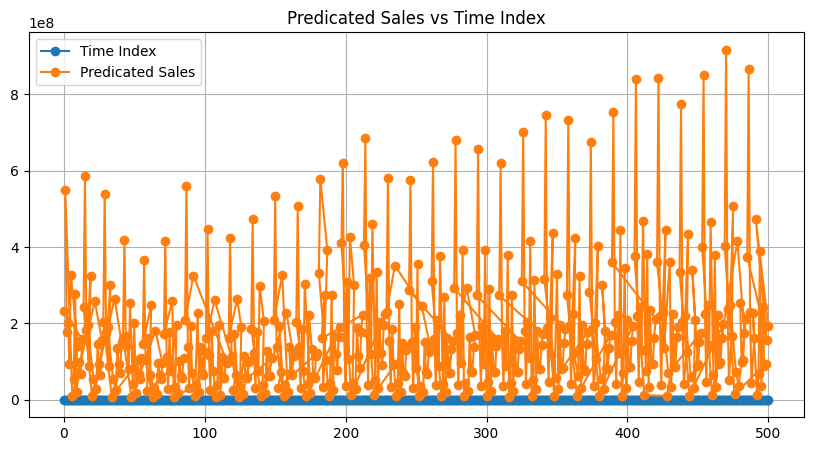

In [205]:
#8️⃣ Visualize Predictions
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))
plt.plot(X, label='Time Index',marker='o')
plt.plot(y, label='Predicated Sales',marker='o')

plt.legend()
plt.title('Predicated Sales vs Time Index')
plt.grid(True)
plt.savefig("sales_trend_TimeIndex.png", dpi=300, bbox_inches='tight')
plt.show()

🎯 In Simple Words

Linear Regression output means:

👉 It finds the best straight line that explains how sales change over time.

If slope is:

Positive → Sales trend is increasing 📈

Negative → Sales trend is decreasing 📉

Near 0 → Sales are flat

In [206]:
# Generate a summary report
report = f"""
Colorado Motor Vehicle Sales Data Analysis Report
=======================================
1. Data Overview
----------------
- Time Frame: {data.index.min()} to {data.index.max()}
- Total Sales Data Points: {len(data)}

2. Exploratory Data Analysis
----------------------------
- Total motor vehicle sales were plotted over time, showing general trends and
seasonality.
1️⃣ Overall Trend (Main Insight)

The blue line (Sales Over Time) shows a clear upward trend from 2008 to 2015.

👉 Sales are generally increasing year by year.
This means business performance is improving over time.

2️⃣ Seasonal Pattern (Quarterly Effect)
Since the x-axis shows:

2008 Q1, Q2, Q3, Q4 … up to 2015 Q4

You can see repeating ups and downs within each year.

📌 That means there is seasonality in the data.

For example:

Some quarters consistently perform higher.

Some quarters drop regularly.

This is common in sales data (festivals, financial year-end, demand cycles, etc.).
"The sales data demonstrates a consistent upward trend with evident quarterly seasonality. Variability in sales increases over time, suggesting business expansion and higher market dynamics."

3. Statistical Analysis
-----------------------
- Seasonal decomposition of total sales showed clear seasonal patterns.
2️⃣ Seasonal Pattern (Quarterly Effect)

Since the x-axis shows:

2008 Q1, Q2, Q3, Q4 … up to 2015 Q4

You can see repeating ups and downs within each year.

📌 That means there is seasonality in the data.

For example:

Some quarters consistently perform higher.

Some quarters drop regularly.

This is common in sales data (festivals, financial year-end, demand cycles, etc.).

4. Predictive Modeling
----------------------
- An ARIMA model was used to forecast motor vehicle sales for the next 12 months.
print(f"forecast: {forecast.iloc[0]:.2f}")
- The model's Mean Squared Error (MSE) was: {mae:.2f}

5. Conclusions
--------------
- The analysis provided insights into the trends and seasonality of motor vehicle sales
in Colorado.
- The predictive model can be used to forecast future sales, aiding in inventory
management and sales strategies.


"""
print(report)


Colorado Motor Vehicle Sales Data Analysis Report
1. Data Overview
----------------
- Time Frame: 0 to 500
- Total Sales Data Points: 501

2. Exploratory Data Analysis
----------------------------
- Total motor vehicle sales were plotted over time, showing general trends and
seasonality.
1️⃣ Overall Trend (Main Insight)

The blue line (Sales Over Time) shows a clear upward trend from 2008 to 2015.

👉 Sales are generally increasing year by year.
This means business performance is improving over time.

2️⃣ Seasonal Pattern (Quarterly Effect)
Since the x-axis shows:

2008 Q1, Q2, Q3, Q4 … up to 2015 Q4

You can see repeating ups and downs within each year.

📌 That means there is seasonality in the data.

For example:

Some quarters consistently perform higher.

Some quarters drop regularly.

This is common in sales data (festivals, financial year-end, demand cycles, etc.).
"The sales data demonstrates a consistent upward trend with evident quarterly seasonality. Variability in sales incr

In [207]:
import os
os.remove("/kaggle/working/yesales_trend.png")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/yesales_trend.png'